<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_10_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №10. Уравнение теплопроводности

**Задача.** Решить одномерное уравнение теплопроводности с источником:

`u_t = u_xx + f(x,t)`, `u(x,0) = φ(x)` — задача Коши на всей прямой.

Нужно воспользоваться формулой Пуассона для представления решения в виде суммы
вклада от начального распределения температуры и вклада от теплового источника, и
получить решение в явном (аналитическом) виде.


Лабораторная работа №10: Распространение тепла
Вариант 9

--- ЗАДАНИЕ 1: Задача Коши ---
Уравнение: du/dt = d²u/dx² + e^{-1/t²}
Начальное условие: u(x,0) = 1

Аналитическое решение:
u(x,t) = 1 + ∫₀ᵗ e^{-1/τ²} dτ
(решение не зависит от x!)


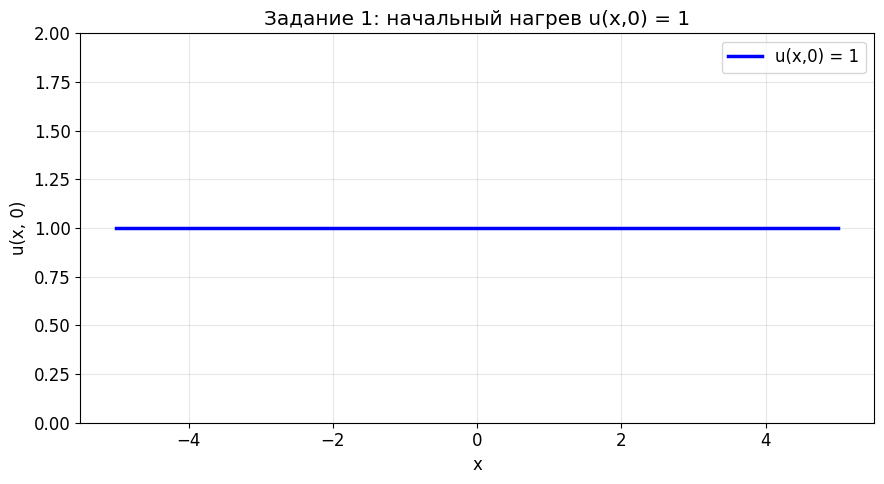


График начального нагрева сохранён.

Значения решения (u не зависит от x):
     t        u(x,t)
   0.5      1.000867
   1.0      1.089074
   2.0      1.707710
   3.0      2.554841
   5.0      4.426223


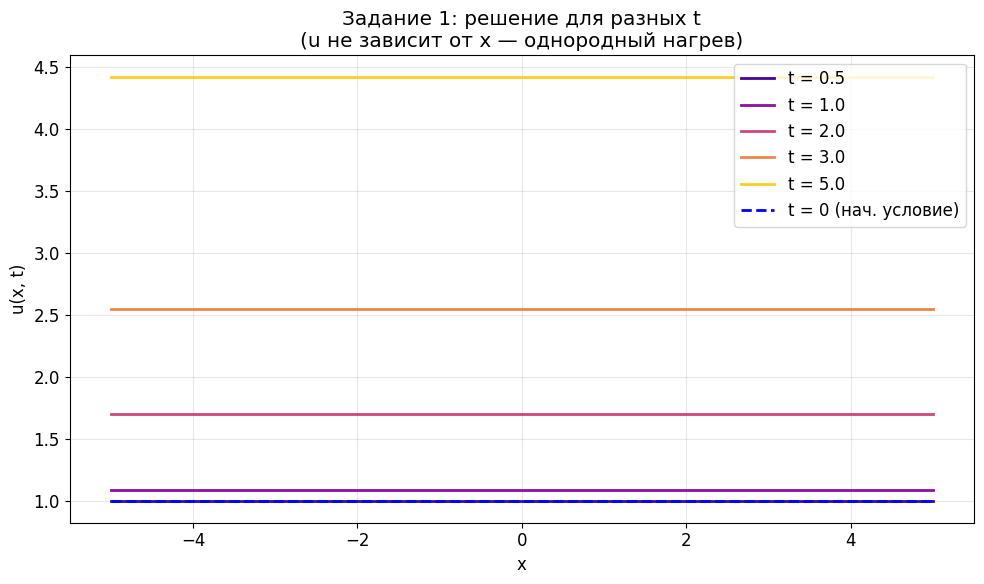

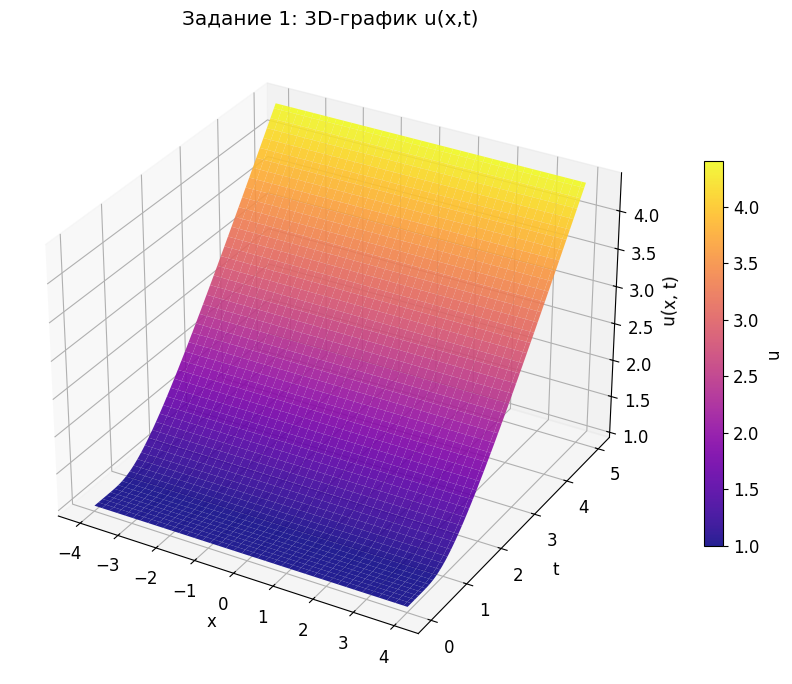

3D-график задания 1 сохранён.

--- ЗАДАНИЕ 2: Смешанная задача (бесконечный стержень) ---
Уравнение: du/dt = 2.0 * d²u/dx²
Начальное условие: u(x,0) = exp(-α·x²),  α = 1.0

Аналитическое решение (формула Пуассона):
u(x,t) = 1/√(1 + 8αt) · exp(-αx²/(1 + 8αt))


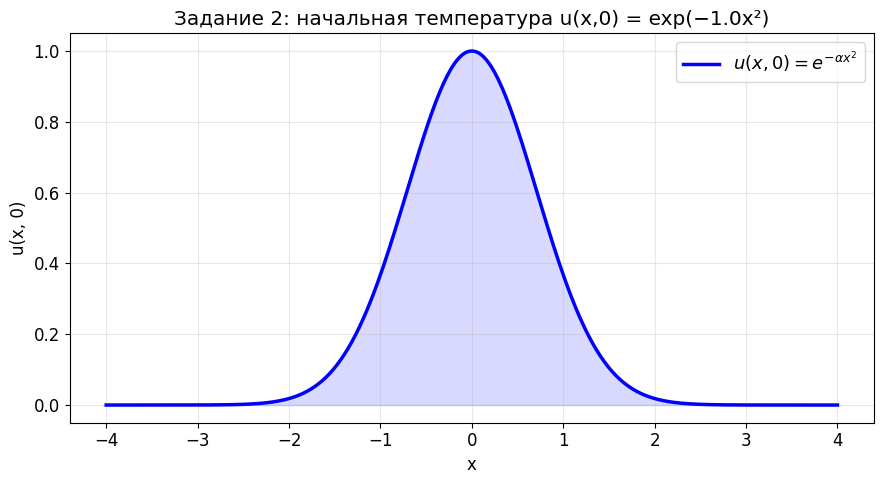


График начальной температуры сохранён.


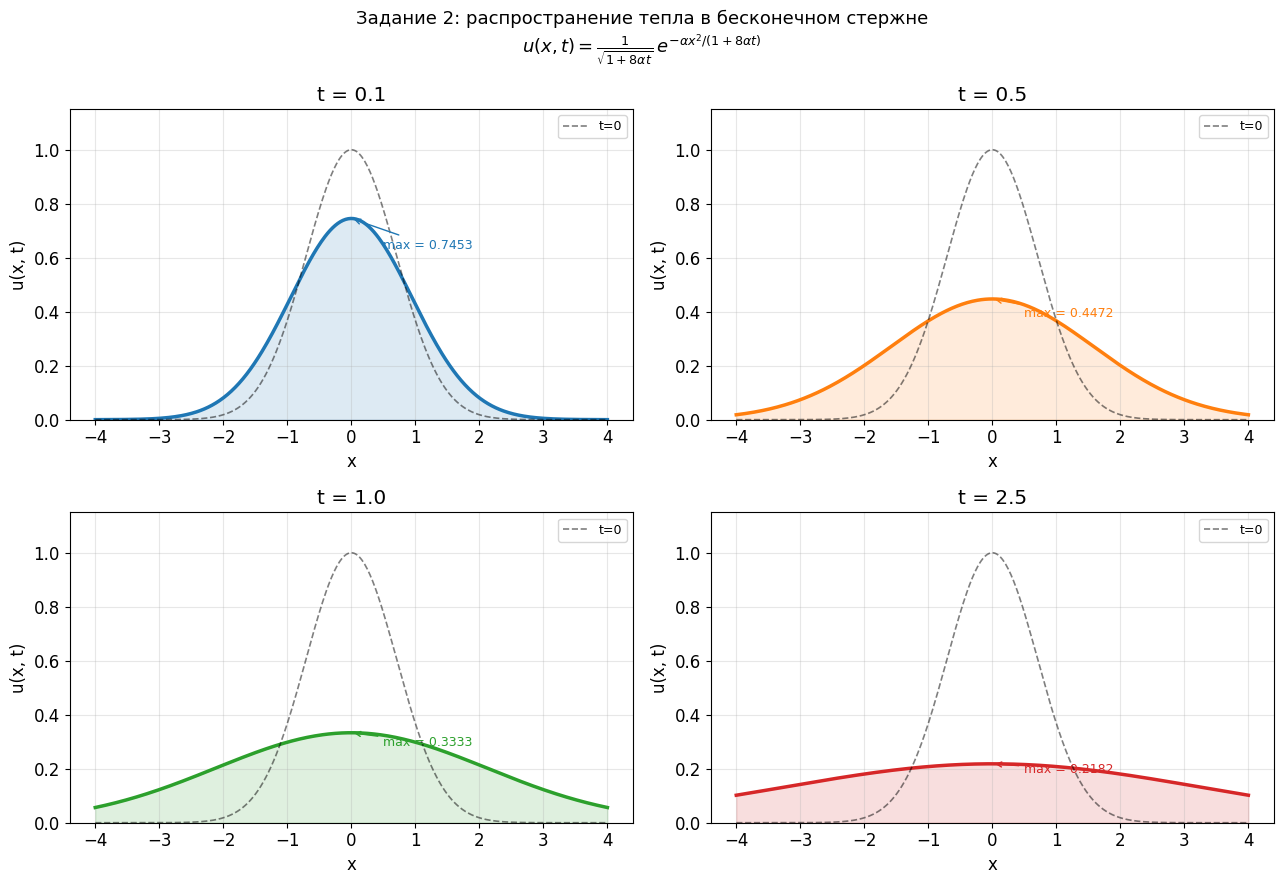

4 графика задания 2 сохранены.


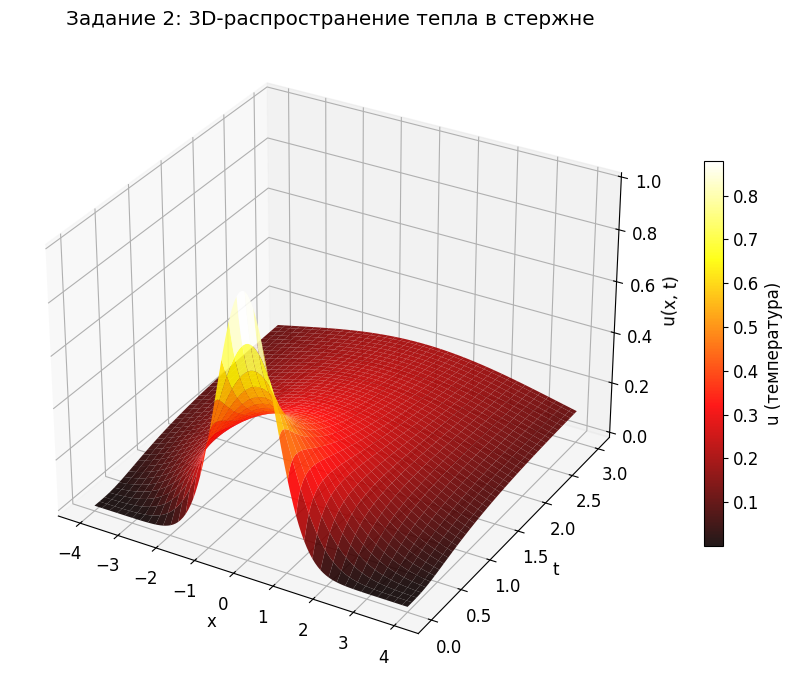

3D-график задания 2 сохранён.

ИТОГИ

Задание 1:
  u(x,t) = 1 + ∫₀ᵗ e^{-1/τ²} dτ
  Решение не зависит от x (источник однороден по пространству).
  При t→0: u→1 (начальное условие выполнено).
  При t→∞: u→1 + √π/2 ≈ 1.886
  u при t=100: 99.237546

Задание 2:
  u(x,t) = 1/√(1+8t) · exp(−x²/(1+8t))
  (при α=1.0, a²=2.0)
  При t=0: u = exp(−x²) ✓
  При t→∞: u→0 (тепло рассеивается по всему стержню).
  Максимум всегда в точке x=0: u(0,t) = 1/√(1+8t)
    t=0.0: u(0,t) = 1.0000
    t=0.1: u(0,t) = 0.7454
    t=0.5: u(0,t) = 0.4472
    t=1.0: u(0,t) = 0.3333
    t=2.5: u(0,t) = 0.2182


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

print("=" * 65)
print("Лабораторная работа №10: Распространение тепла")
print("Вариант 9")
print("=" * 65)

# ================================================================
# ЗАДАНИЕ 1: Задача Коши
# ================================================================
# du/dt = d²u/dx² + e^{-1/t²},   t > 0,  -inf < x < inf
# u(x, 0) = 1
#
# Решение по формуле Пуассона (9):
#
# u(x,t) = I1(x,t) + I2(x,t), где
#
# I1 — от начального условия phi(x) = 1:
#   I1 = 1/(2*sqrt(pi*t)) * integral_{-inf}^{inf} e^{-(xi-x)^2/(4t)} dxi = 1
#   (гауссов интеграл равен 2*sqrt(pi*t), делим — получаем 1)
#
# I2 — от источника f(x,t) = e^{-1/t²} (не зависит от x!):
#   I2 = 1/(2*sqrt(pi)) * integral_0^t [ 1/sqrt(t-tau) *
#        integral_{-inf}^{inf} e^{-1/tau^2} * e^{-(xi-x)^2/(4a^2(t-tau))} dxi ] dtau
#
# Внутренний интеграл по xi (a^2=1):
#   integral_{-inf}^{inf} e^{-(xi-x)^2/(4(t-tau))} dxi = 2*sqrt(pi*(t-tau))
#
# Поэтому:
#   I2 = 1/(2*sqrt(pi)) * integral_0^t e^{-1/tau^2} * 2*sqrt(pi(t-tau)) / sqrt(t-tau) dtau
#      = integral_0^t e^{-1/tau^2} dtau
#
# Итоговое аналитическое решение:
#   u(x, t) = 1 + integral_0^t e^{-1/tau^2} dtau

print("\n--- ЗАДАНИЕ 1: Задача Коши ---")
print("Уравнение: du/dt = d²u/dx² + e^{-1/t²}")
print("Начальное условие: u(x,0) = 1")
print("\nАналитическое решение:")
print("u(x,t) = 1 + ∫₀ᵗ e^{-1/τ²} dτ")
print("(решение не зависит от x!)")

def u_task1(x, t):
    """Аналитическое решение задачи 1."""
    if t <= 1e-10:
        return np.ones_like(x) if hasattr(x, '__len__') else 1.0
    # Числовое вычисление интеграла от 0 до t
    eps = 1e-8
    integrand = lambda tau: np.exp(-1.0 / tau**2) if tau > eps else 0.0
    val, _ = integrate.quad(integrand, eps, t, limit=200)
    if hasattr(x, '__len__'):
        return np.ones_like(x, dtype=float) + val
    return 1.0 + val

# --- График 1: начальный нагрев ---
x_plot = np.linspace(-5, 5, 300)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_plot, np.ones_like(x_plot), 'b-', linewidth=2.5, label='u(x,0) = 1')
ax.set_xlabel('x')
ax.set_ylabel('u(x, 0)')
ax.set_title('Задание 1: начальный нагрев u(x,0) = 1')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 2)
plt.tight_layout()
plt.show()
print("\nГрафик начального нагрева сохранён.")

# --- Значения интеграла для t = 0.5, 1, 2, 3, 5 ---
t_values = [0.5, 1.0, 2.0, 3.0, 5.0]
print("\nЗначения решения (u не зависит от x):")
print(f"{'t':>6}  {'u(x,t)':>12}")
for tv in t_values:
    uval = u_task1(0, tv)
    print(f"{tv:>6.1f}  {uval:>12.6f}")

# --- 5 плоских графиков для разных t ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_values)))
for tv, col in zip(t_values, colors):
    uval = u_task1(0, tv)
    ax.plot(x_plot, np.full_like(x_plot, uval),
            color=col, linewidth=2, label=f't = {tv}')
ax.plot(x_plot, np.ones_like(x_plot), 'b--',
        linewidth=2, label='t = 0 (нач. условие)', zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('u(x, t)')
ax.set_title('Задание 1: решение для разных t\n(u не зависит от x — однородный нагрев)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3D-график ---
t_3d = np.linspace(0.01, 5, 100)
x_3d = np.linspace(-4, 4, 80)
X3, T3 = np.meshgrid(x_3d, t_3d)

U3 = np.zeros_like(T3)
for i, tv in enumerate(t_3d):
    uval = u_task1(0, tv)
    U3[i, :] = uval

fig = plt.figure(figsize=(11, 7))
ax3d = fig.add_subplot(111, projection='3d')
surf = ax3d.plot_surface(X3, T3, U3, cmap='plasma', edgecolor='none', alpha=0.9)
ax3d.set_xlabel('x')
ax3d.set_ylabel('t')
ax3d.set_zlabel('u(x, t)')
ax3d.set_title('Задание 1: 3D-график u(x,t)')
fig.colorbar(surf, ax=ax3d, shrink=0.6, label='u')
plt.tight_layout()
plt.show()
print("3D-график задания 1 сохранён.")

# ================================================================
# ЗАДАНИЕ 2: Смешанная задача (бесконечный стержень)
# ================================================================
# Начальная температура: u(x,0) = e^{-alpha*x²}
# Боковая поверхность теплоизолирована
# Стержень бесконечный => задача Коши на всей прямой
# a² = 2
#
# du/dt = 2 * d²u/dx²,   t > 0,  -inf < x < inf
# u(x,0) = e^{-alpha*x²}
#
# Решение по формуле Пуассона (2) с a² = 2 (a = sqrt(2)):
#
# u(x,t) = 1/(2a*sqrt(pi*t)) * integral_{-inf}^{inf} e^{-alpha*xi²}
#                                          * e^{-(xi-x)²/(4a²t)} dxi
#
# Вычисляем: показатель степени в подынтегральном выражении:
#   -alpha*xi² - (xi-x)²/(8t)
#   = -(alpha + 1/(8t))*xi² + x/(4t)*xi - x²/(8t)
#   = -(alpha + 1/(8t))*(xi - x/(8t*(alpha+1/(8t))))² + ...
#
# После вычисления гауссова интеграла:
#   u(x,t) = 1/sqrt(1 + 8*alpha*t) * exp(-alpha*x²/(1 + 8*alpha*t))
#
# (при a²=2 => 4a²=8)

alpha = 1.0   # параметр альфа (можно менять)
a2 = 2.0      # коэффициент температуропроводности
a  = np.sqrt(a2)

print("\n" + "=" * 65)
print("--- ЗАДАНИЕ 2: Смешанная задача (бесконечный стержень) ---")
print(f"Уравнение: du/dt = {a2} * d²u/dx²")
print(f"Начальное условие: u(x,0) = exp(-α·x²),  α = {alpha}")
print("\nАналитическое решение (формула Пуассона):")
print("u(x,t) = 1/√(1 + 8αt) · exp(-αx²/(1 + 8αt))")

def u_task2(x, t, alpha=1.0, a2=2.0):
    """
    Аналитическое решение задачи Коши для бесконечного стержня.
    u(x,t) = 1/sqrt(1 + 4*a2*alpha*t) * exp(-alpha*x^2 / (1 + 4*a2*alpha*t))
    """
    denom = 1.0 + 4.0 * a2 * alpha * t
    return (1.0 / np.sqrt(denom)) * np.exp(-alpha * x**2 / denom)

# --- График начальной температуры ---
x_plot2 = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_plot2, np.exp(-alpha * x_plot2**2), 'b-',
        linewidth=2.5, label=r'$u(x,0) = e^{-\alpha x^2}$')
ax.fill_between(x_plot2, np.exp(-alpha * x_plot2**2), alpha=0.15, color='blue')
ax.set_xlabel('x')
ax.set_ylabel('u(x, 0)')
ax.set_title(f'Задание 2: начальная температура u(x,0) = exp(−{alpha}x²)')
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\nГрафик начальной температуры сохранён.")

# --- 4 графика для разных моментов времени ---
t_moments = [0.1, 0.5, 1.0, 2.5]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
colors2 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (tv, col) in enumerate(zip(t_moments, colors2)):
    u_vals = u_task2(x_plot2, tv, alpha, a2)
    axes[idx].plot(x_plot2, u_vals, color=col, linewidth=2.5)
    axes[idx].plot(x_plot2, np.exp(-alpha * x_plot2**2),
                   'k--', linewidth=1.2, alpha=0.5, label='t=0')
    axes[idx].fill_between(x_plot2, u_vals, alpha=0.15, color=col)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('u(x, t)')
    axes[idx].set_title(f't = {tv}')
    axes[idx].set_ylim(0, 1.15)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    umax = np.max(u_vals)
    axes[idx].annotate(f'max = {umax:.4f}', xy=(0, umax),
                       xytext=(0.5, umax*0.85),
                       fontsize=9, color=col,
                       arrowprops=dict(arrowstyle='->', color=col))

plt.suptitle('Задание 2: распространение тепла в бесконечном стержне\n'
             r'$u(x,t) = \frac{1}{\sqrt{1+8\alpha t}}\,e^{-\alpha x^2/(1+8\alpha t)}$',
             fontsize=13)
plt.tight_layout()
plt.show()
print("4 графика задания 2 сохранены.")

# --- 3D-график задания 2 ---
t_3d2 = np.linspace(0.001, 3, 120)
x_3d2 = np.linspace(-4, 4, 120)
X2, T2 = np.meshgrid(x_3d2, t_3d2)
U2 = u_task2(X2, T2, alpha, a2)

fig = plt.figure(figsize=(11, 7))
ax3d2 = fig.add_subplot(111, projection='3d')
surf2 = ax3d2.plot_surface(X2, T2, U2, cmap='hot', edgecolor='none', alpha=0.9)
ax3d2.set_xlabel('x')
ax3d2.set_ylabel('t')
ax3d2.set_zlabel('u(x, t)')
ax3d2.set_title('Задание 2: 3D-распространение тепла в стержне')
fig.colorbar(surf2, ax=ax3d2, shrink=0.6, label='u (температура)')
plt.tight_layout()
plt.show()
print("3D-график задания 2 сохранён.")

# --- Сводный итоговый вывод ---
print("\n" + "=" * 65)
print("ИТОГИ")
print("=" * 65)
print("\nЗадание 1:")
print("  u(x,t) = 1 + ∫₀ᵗ e^{-1/τ²} dτ")
print("  Решение не зависит от x (источник однороден по пространству).")
print("  При t→0: u→1 (начальное условие выполнено).")
print("  При t→∞: u→1 + √π/2 ≈ 1.886")
inf_val = 1 + integrate.quad(lambda tau: np.exp(-1/tau**2), 1e-8, 100)[0]
print(f"  u при t=100: {inf_val:.6f}")

print("\nЗадание 2:")
print(f"  u(x,t) = 1/√(1+8t) · exp(−x²/(1+8t))")
print(f"  (при α={alpha}, a²={a2})")
print("  При t=0: u = exp(−x²) ✓")
print("  При t→∞: u→0 (тепло рассеивается по всему стержню).")
print("  Максимум всегда в точке x=0: u(0,t) = 1/√(1+8t)")
for tv in [0, 0.1, 0.5, 1.0, 2.5]:
    umax = 1.0 / np.sqrt(1 + 8*alpha*tv) if tv > 0 else 1.0
    print(f"    t={tv:.1f}: u(0,t) = {umax:.4f}")
